In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
data=pd.read_csv("C:\\Users\\kagid\\OneDrive - Ashesi University\\Deeplearning\\archive\\StudentPerformanceFactors.csv")
data.shape

(6607, 20)

In [ ]:

# Identify categorical columns
categorical_cols = data.select_dtypes(include='object').columns
print("Categorical Columns:\n", categorical_cols)

# Prepare lists for encoding
one_hot_cols = []
for col in categorical_cols:
    if data[col].nunique() == 2:
        data[col] = data[col].astype('category').cat.codes
        print(f"Binary encoded: {col}")
    elif data[col].nunique() <= 10:
        one_hot_cols.append(col)
    else:
        freq_map = data[col].value_counts(normalize=True).to_dict()
        data[col+'_freq'] = data[col].map(freq_map)
        data.drop(col, axis=1, inplace=True)
        print(f"Frequency encoded: {col} (high cardinality)")

# One-hot encode all at once
if one_hot_cols:
    data = pd.get_dummies(data, columns=one_hot_cols, prefix=one_hot_cols)
    print(f"One-hot encoded: {one_hot_cols} (low cardinality)")



In [ ]:
print("\nNumber of duplicates:", data.duplicated().sum())

# Remove duplicates if any exist
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
    print("Duplicates removed. New shape:", data.shape)
else:
    print("No duplicates found.")


Number of duplicates: 0
No duplicates found.



Descriptive statistics for numeric features:
       Hours_Studied   Attendance  Sleep_Hours  Previous_Scores  \
count    6378.000000  6378.000000  6378.000000      6378.000000   
mean       19.977109    80.020853     7.034964        75.066165   
std         5.985460    11.550723     1.468033        14.400389   
min         1.000000    60.000000     4.000000        50.000000   
25%        16.000000    70.000000     6.000000        63.000000   
50%        20.000000    80.000000     7.000000        75.000000   
75%        24.000000    90.000000     8.000000        88.000000   
max        44.000000   100.000000    10.000000       100.000000   

       Tutoring_Sessions  Physical_Activity   Exam_Score  
count        6378.000000        6378.000000  6378.000000  
mean            1.495296           2.972719    67.252117  
std             1.233984           1.028926     3.914217  
min             0.000000           0.000000    55.000000  
25%             1.000000           2.000000    65.00000

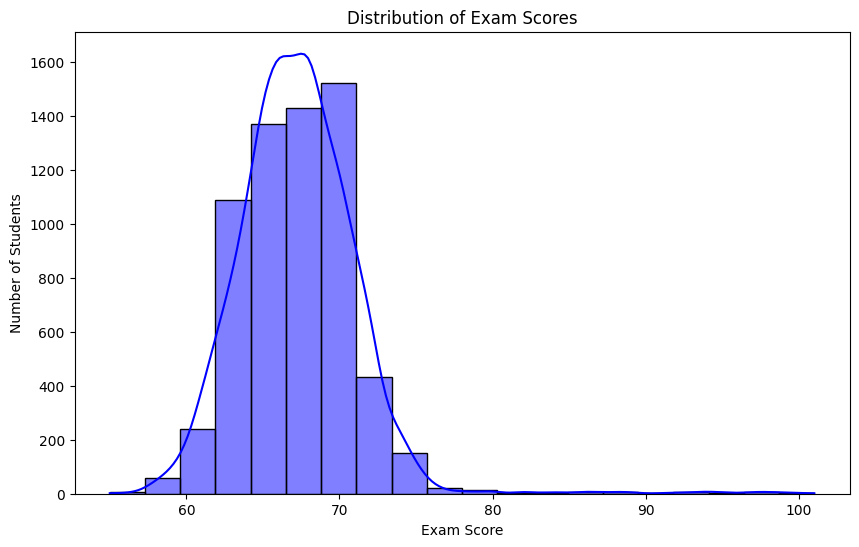

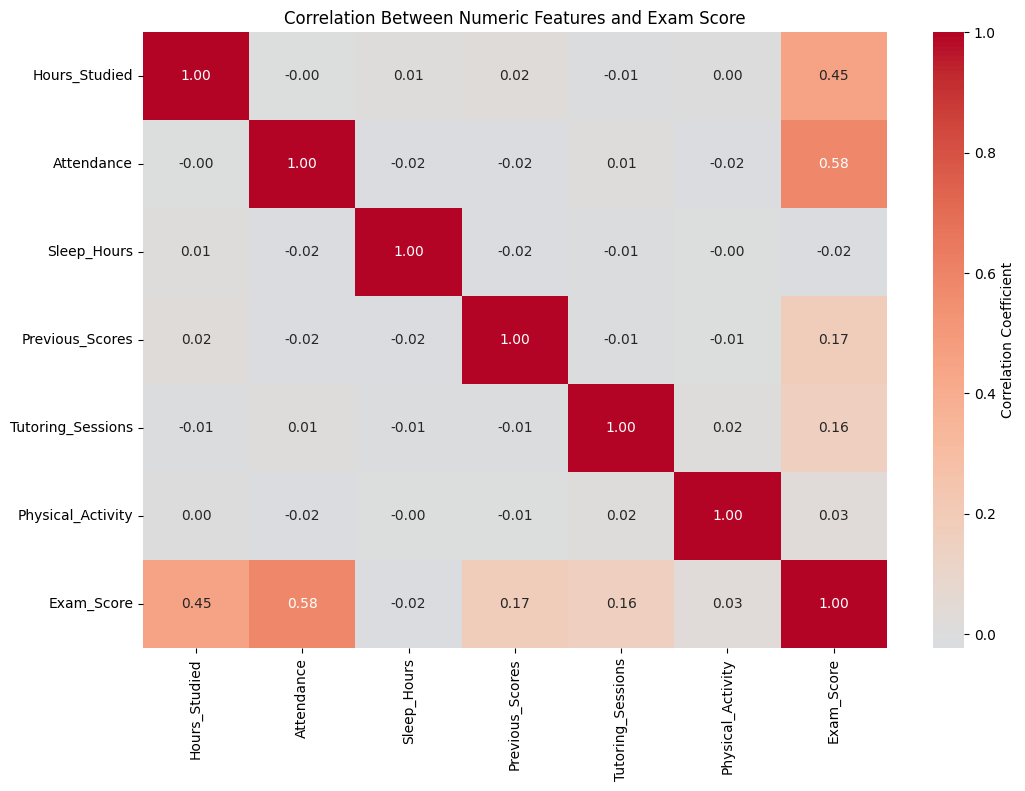


Top 3 correlated numeric features:
1. Attendance (correlation: 0.58)
2. Hours_Studied (correlation: 0.45)
3. Previous_Scores (correlation: 0.17)


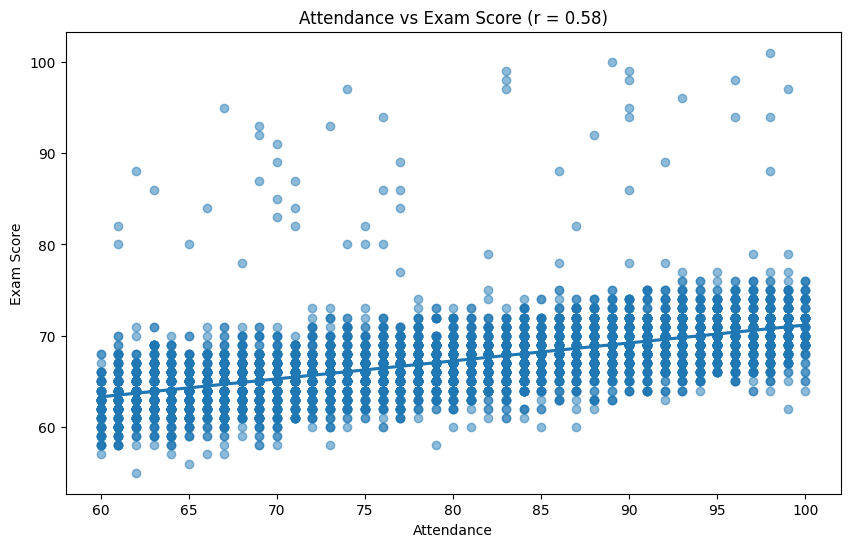

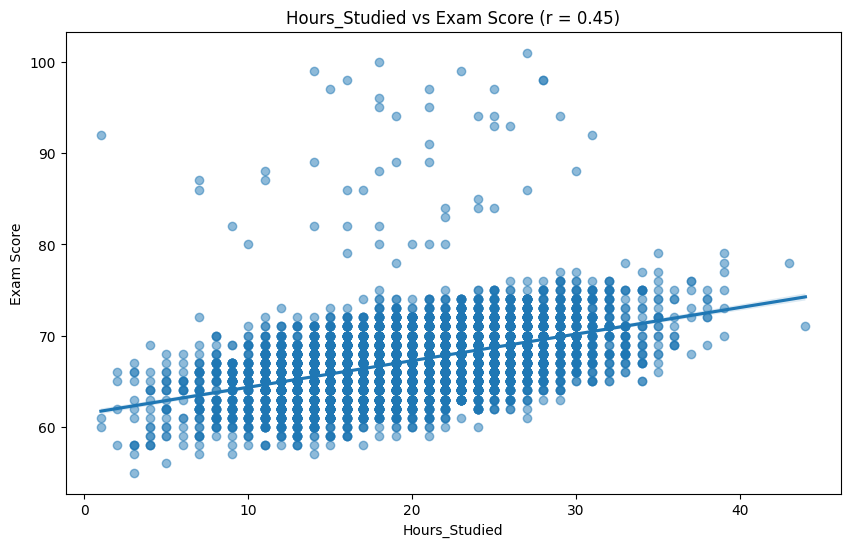

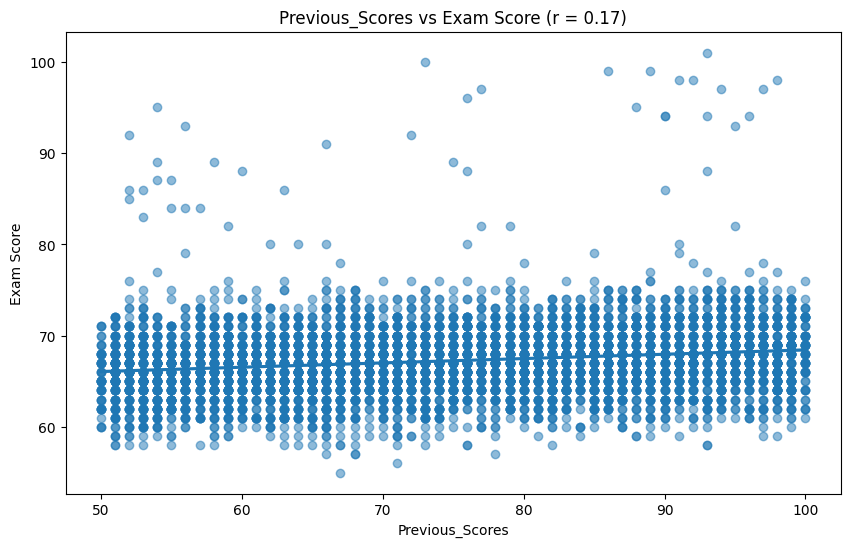


Analyzing categorical features vs exam scores:


In [ ]:


#2 Data Cleaning & Preparation
# Remove missing values
data.dropna(inplace=True)

# Remove duplicates if any exist
print("\nNumber of duplicates:", data.duplicated().sum())
if data.duplicated().sum() > 0:
    data = data.drop_duplicates()
    print("Duplicates removed. New shape:", data.shape)
else:
    print("No duplicates found.")

# Identify categorical columns
categorical_cols = data.select_dtypes(include='object').columns
print("Categorical Columns:\n", categorical_cols)

# Feature Engineering

print("\nEncoding categorical features:")
for col in categorical_cols:
    # For binary categories (Yes/No, Male/Female etc.)
    if data[col].nunique() == 2:
        data[col] = data[col].astype('category').cat.codes
        print(f"Binary encoded: {col}")
    # For low-cardinality categories (3-10 unique values)
    elif data[col].nunique() <= 10:
        data = pd.get_dummies(data, columns=[col], prefix=col)
        print(f"One-hot encoded: {col} (low cardinality)")
    # For high-cardinality categories
    else:
        freq_map = data[col].value_counts(normalize=True).to_dict()
        data[col+'_freq'] = data[col].map(freq_map)
        data.drop(col, axis=1, inplace=True)
        print(f"Frequency encoded: {col} (high cardinality)")

# Handle any remaining missing values
data.fillna(data.median(), inplace=True)

# Create feature matrix X and target y
X = data.drop('Exam_Score', axis=1)
y = data['Exam_Score']

# Scale numeric features
scaler = StandardScaler()
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("\nFinal feature matrix shape:", X.shape)





In [ ]:

# 4-5. Model Preparation & Building


# Split data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train linear regression
model = LinearRegression()
model.fit(X_train, y_train)

# Show most important features
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)

print("\nTop 5 most influential features:")
print(coef_df.head(5))


Top 5 most influential features:
                      Feature  Coefficient
1                  Attendance     2.294826
0               Hours_Studied     1.770563
15    Access_to_Resources_Low    -1.029940
14   Access_to_Resources_High     1.020382
11  Parental_Involvement_High     1.016958


In [ ]:

# 6. Prediction & Evaluation


y_pred = model.predict(X_test)

print("\nModel Performance:")
print(f"- MAE: {mean_absolute_error(y_test, y_pred):.2f}")
print(f"- RMSE: {np.sqrt(mean_squared_error(y_test, y_pred)):.2f}") 
print(f"- R²: {r2_score(y_test, y_pred):.2f}")


Model Performance:
- MAE: 0.45
- RMSE: 1.80
- R²: 0.77


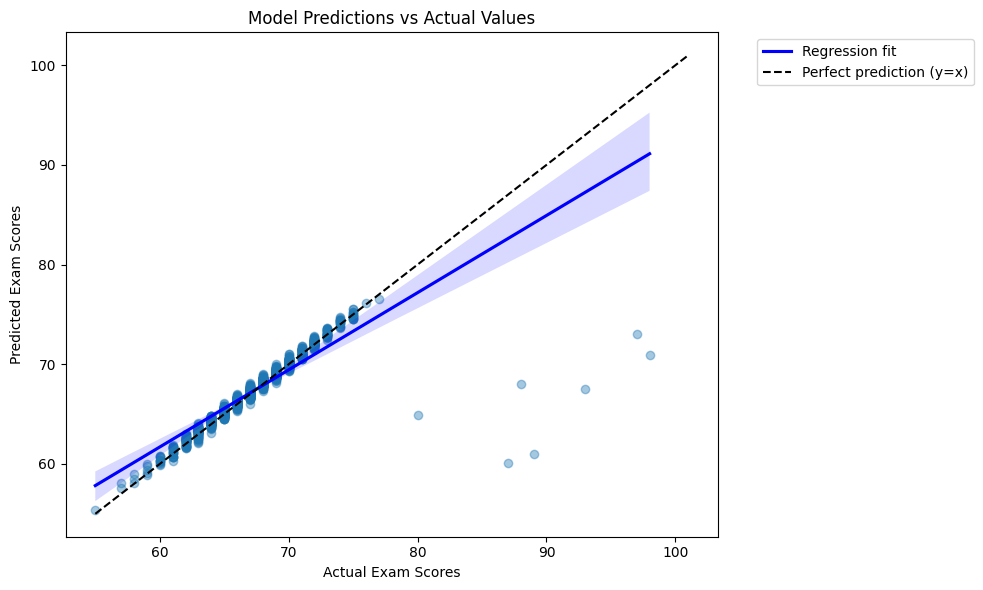

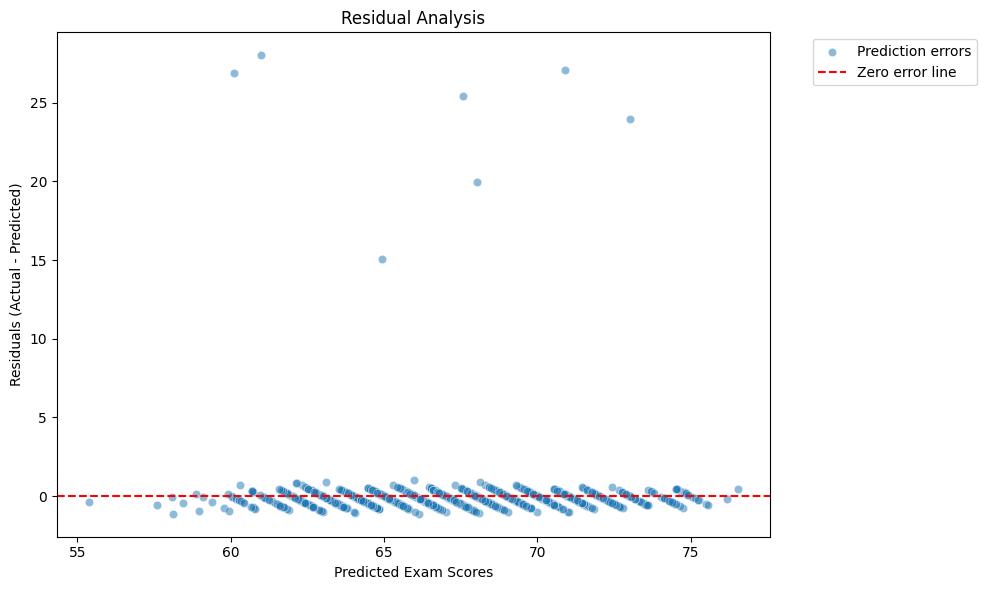

In [ ]:

# Visualization (With Clearer Labels)

# Actual vs Predicted plot
plt.figure(figsize=(10, 6))
sns.regplot(x=y_test, y=y_pred, scatter_kws={'alpha':0.4, 'label':'Data points'}, 
            line_kws={'color':'blue', 'label':'Regression fit'})
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', label='Perfect prediction (y=x)')
plt.xlabel('Actual Exam Scores')
plt.ylabel('Predicted Exam Scores')
plt.title('Model Predictions vs Actual Values')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Corrected parameter name
plt.tight_layout()  # Ensures legend doesn't get cut off
plt.show()
residuals = y_test - y_pred
# Residual plot
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals, alpha=0.5, label='Prediction errors')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1.5, label='Zero error line')
plt.xlabel('Predicted Exam Scores')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Analysis')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')  # Corrected parameter name
plt.tight_layout()  # Ensures legend doesn't get cut off
plt.show()

# Bonus: Polynomial Regression 

from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

# Create a pipeline that adds polynomial features then fits linear regression
poly_degree = 2
poly_model = make_pipeline(PolynomialFeatures(degree=poly_degree), LinearRegression())

# Fit the polynomial model on the training data
poly_model.fit(X_train, y_train)

# Predict on the test set
y_poly_pred = poly_model.predict(X_test)

# Evaluate polynomial regression
print("\nPolynomial Regression Performance (degree=2):")
print(f"- MAE: {mean_absolute_error(y_test, y_poly_pred):.2f}")
print(f"- RMSE: {np.sqrt(mean_squared_error(y_test, y_poly_pred)):.2f}")
print(f"- R²: {r2_score(y_test, y_poly_pred):.2f}")

# Visualize: Actual vs Polynomial Predicted
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_poly_pred, alpha=0.5, label='Polynomial Predictions')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', label='Perfect prediction (y=x)')
plt.xlabel('Actual Exam Scores')
plt.ylabel('Polynomial Predicted Exam Scores')
plt.title('Polynomial Model Predictions vs Actual Values')
plt.legend()
plt.tight_layout()
plt.show()


In [ ]:

#Bonus: Cross-Validation 
# Make sure X and y are defined (from previous steps)
if 'X' in locals() and 'y' in locals():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"\nCross-Validation R² Scores: {cv_scores}")
    print(f"Average CV R²: {cv_scores.mean():.2f} (±{cv_scores.std():.2f})")
else:
    print("Error: X and y not found. Please run previous steps first.")

# Optional: Detailed cross-validation with more metrics
from sklearn.model_selection import cross_validate

scoring = {'r2': 'r2',
           'neg_mae': 'neg_mean_absolute_error',
           'neg_rmse': 'neg_root_mean_squared_error'}

cv_results = cross_validate(model, X, y, cv=5, scoring=scoring)
print("\nDetailed Cross-Validation:")
print(f"R²: {cv_results['test_r2'].mean():.2f} (±{cv_results['test_r2'].std():.2f})")
print(f"MAE: {-cv_results['test_neg_mae'].mean():.2f} (±{cv_results['test_neg_mae'].std():.2f})")
print(f"RMSE: {-cv_results['test_neg_rmse'].mean():.2f} (±{cv_results['test_neg_rmse'].std():.2f})")


Cross-Validation R² Scores: [0.6258018  0.72342248 0.70837147 0.73331539 0.84045951]
Average CV R²: 0.73 (±0.07)

Detailed Cross-Validation:
R²: 0.73 (±0.07)
MAE: 0.49 (±0.04)
RMSE: 2.02 (±0.29)


In [ ]:
# Single-feature model (study hours only)
simple_model = LinearRegression()
simple_model.fit(X_train[['Hours_Studied']], y_train)
simple_r2 = r2_score(y_test, simple_model.predict(X_test[['Hours_Studied']]))
print(f"Study-hours-only model R²: {simple_r2:.2f}")

Study-hours-only model R²: 0.23


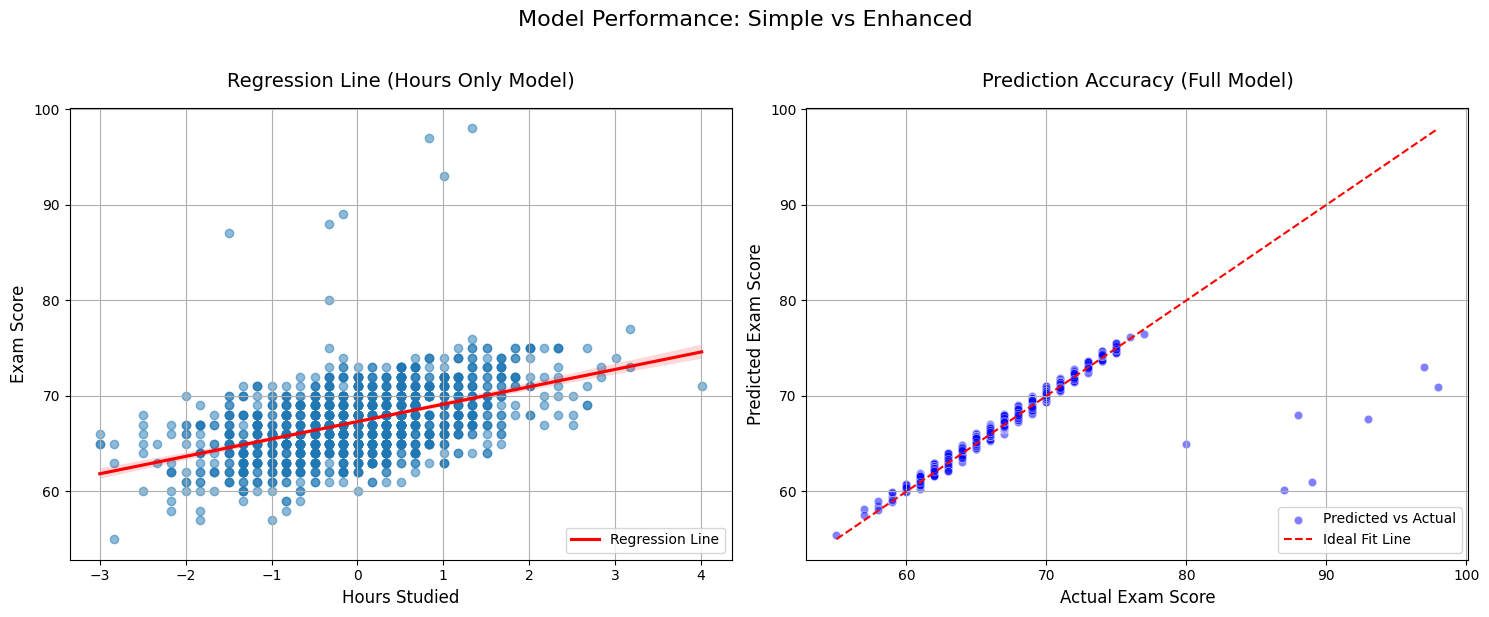

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting side-by-side comparison of simple vs full regression models
fig, ax = plt.subplots(1, 2, figsize=(15, 6))  # Create 1 row with 2 plots

# Plot 1: Simple Linear Regression with Hours Only
sns.regplot(
    x=X_test['Hours_Studied'],
    y=y_test,
    ax=ax[0],
    scatter_kws={'alpha': 0.5, 'label': 'Test Data'},
    line_kws={'color': 'red', 'label': 'Regression Line'}
)
ax[0].set_title("Regression Line (Hours Only Model)", fontsize=14, pad=15)
ax[0].set_xlabel("Hours Studied", fontsize=12)
ax[0].set_ylabel("Exam Score", fontsize=12)
ax[0].legend(loc='lower right')
ax[0].grid(True)

# Plot 2: Full Model Comparison (y_test vs y_pred)
sns.scatterplot(
    x=y_test,
    y=y_pred,
    ax=ax[1],
    alpha=0.5,
    color='blue',
    label='Predicted vs Actual'
)
ax[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    label='Ideal Fit Line'
)
ax[1].set_title("Prediction Accuracy (Full Model)", fontsize=14, pad=15)
ax[1].set_xlabel("Actual Exam Score", fontsize=12)
ax[1].set_ylabel("Predicted Exam Score", fontsize=12)
ax[1].legend(loc='lower right')
ax[1].grid(True)

# Overall layout adjustments
plt.suptitle("Model Performance: Simple vs Enhanced", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
